### IMPORTS

In [1]:
import os
import numpy as numpy
import seaborn as seaborn
import matplotlib.pyplot as plot
import tensorflow as tensorflow
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight
from tensorflow.keras.applications.resnet50 import preprocess_input

### REPRODUCIBILITY

In [2]:
numpy.random.seed(42)
tensorflow.random.set_seed(42)

### SET PARAMETERS

In [3]:
image_height = 224
image_width = 224
batch_size = 32

train_path = "../data/brain_tumor/training"
test_path = "../data/brain_tumor/testing"

### DATA AUGMENTATION

In [4]:
train_augmenter = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.1,
    brightness_range=[0.8, 1.2])

validation_augmenter = ImageDataGenerator(preprocessing_function=preprocess_input)
test_augmenter = ImageDataGenerator(preprocessing_function=preprocess_input)

### DATA LOADERS

In [5]:
train_loader = train_augmenter.flow_from_directory(
    train_path,
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True)

validation_loader = train_augmenter.flow_from_directory(
    train_path,
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False)

test_loader = test_augmenter.flow_from_directory(
    test_path,
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False)

Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


### SAMPLE COUNTS

In [6]:
print("Training samples:", train_loader.samples)
print("Validation samples:", validation_loader.samples)
print("Testing samples:", test_loader.samples)

Training samples: 4571
Validation samples: 1141
Testing samples: 1311


### CLASS WEIGHTS

In [7]:
train_labels = train_loader.classes
label_names = list(train_loader.class_indices.keys())

class_weight_values = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=numpy.unique(train_labels),
    y=train_labels)

class_weights = dict(enumerate(class_weight_values))
print("Class weights:", class_weights)

Class weights: {0: 1.0811258278145695, 1: 1.0659981343283582, 2: 0.8955721003134797, 3: 0.9800600343053173}


### SAMPLE BATCH VISUALIZATION

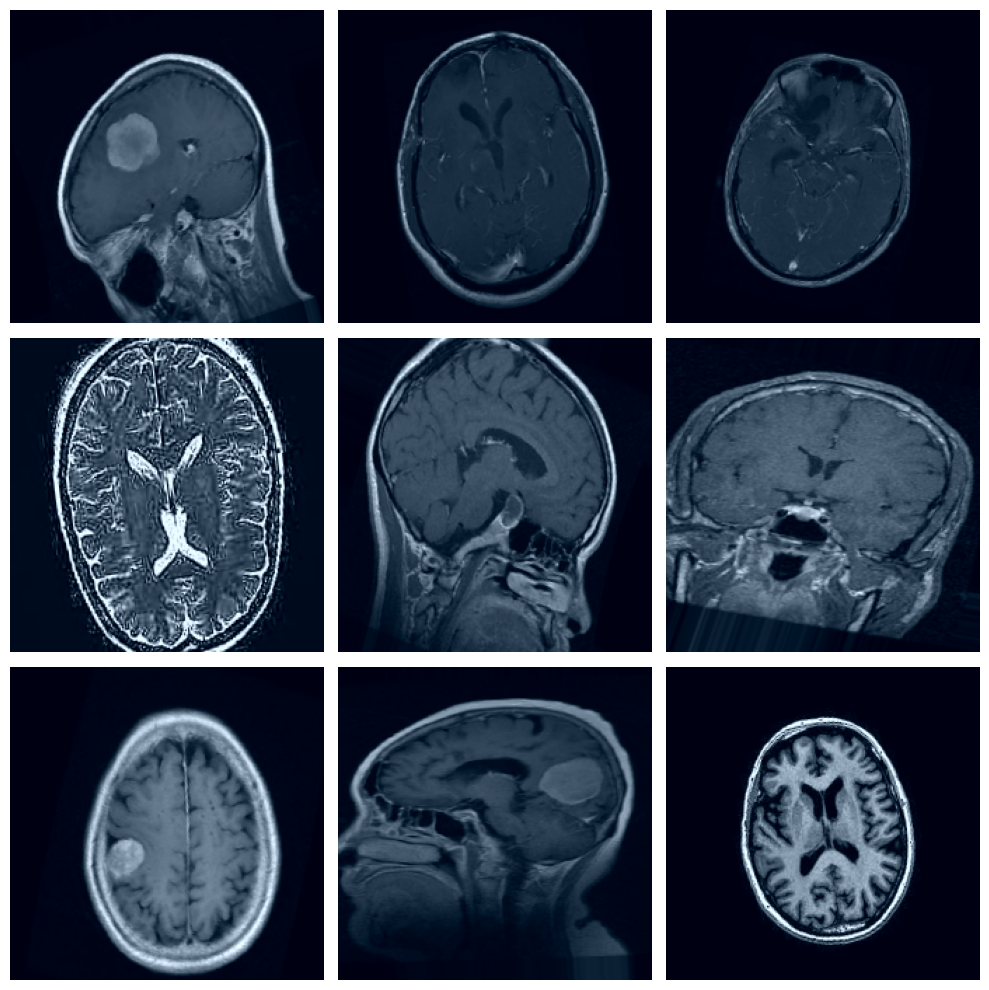

In [8]:
batch_images, batch_labels = next(train_loader)

# Reverse preprocess_input for display: unnormalize ImageNet means
mean = numpy.array([103.939, 116.779, 123.68])  # BGR ImageNet means
display_images = batch_images[..., ::-1] + mean  # BGR->RGB and add means back
display_images = numpy.clip(display_images / 255.0, 0, 1)

plot.figure(figsize=(10, 10))
for image_index in range(9):
    plot.subplot(3, 3, image_index + 1)
    plot.imshow(display_images[image_index])
    plot.axis('off')
plot.tight_layout()
plot.show()


### CLASS DISTRIBUTION

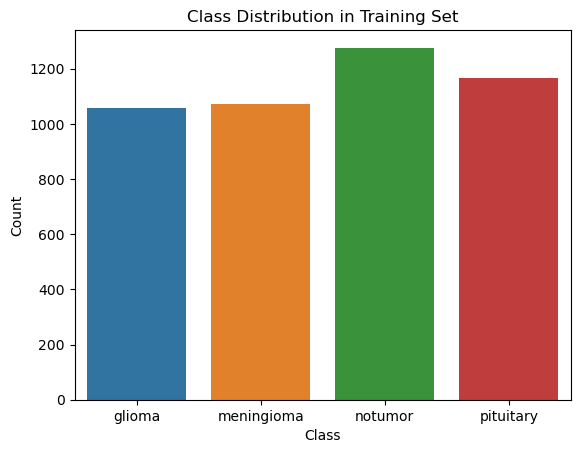

In [9]:
seaborn.countplot(x=[label_names[class_index] for class_index in train_labels])
plot.title("Class Distribution in Training Set")
plot.xlabel("Class")
plot.ylabel("Count")
plot.show()

### AUGMENTED IMAGES

Found 4571 images belonging to 4 classes.


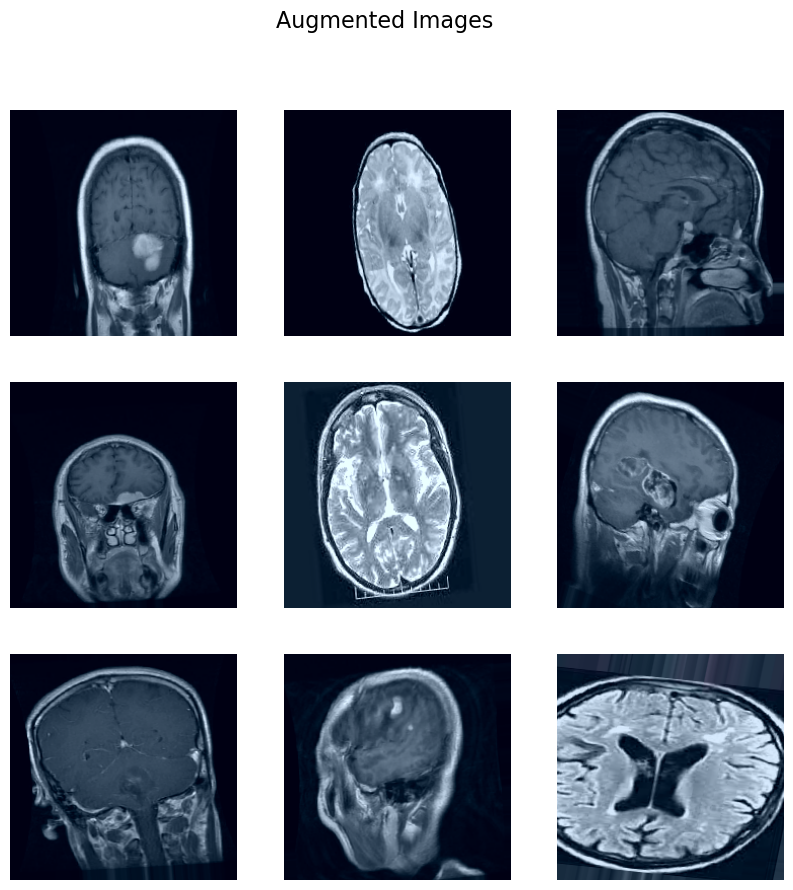

In [10]:
preview_loader = train_augmenter.flow_from_directory(
    train_path,
    target_size=(image_height, image_width),
    batch_size=1,
    class_mode='categorical',
    subset='training',
    shuffle=True)

augmented_images = [
    next(preview_loader)[0][0]
    for preview_index in range(9)]

# Reverse preprocess_input for display
mean = numpy.array([103.939, 116.779, 123.68])
display_augmented = [
    numpy.clip((img[..., ::-1] + mean) / 255.0, 0, 1)
    for img in augmented_images]

plot.figure(figsize=(10, 10))
for image_index in range(9):
    plot.subplot(3, 3, image_index + 1)
    plot.imshow(display_augmented[image_index])
    plot.axis('off')
plot.suptitle('Augmented Images', fontsize=16)
plot.show()


### SAMPLE IMAGES PER CLASS

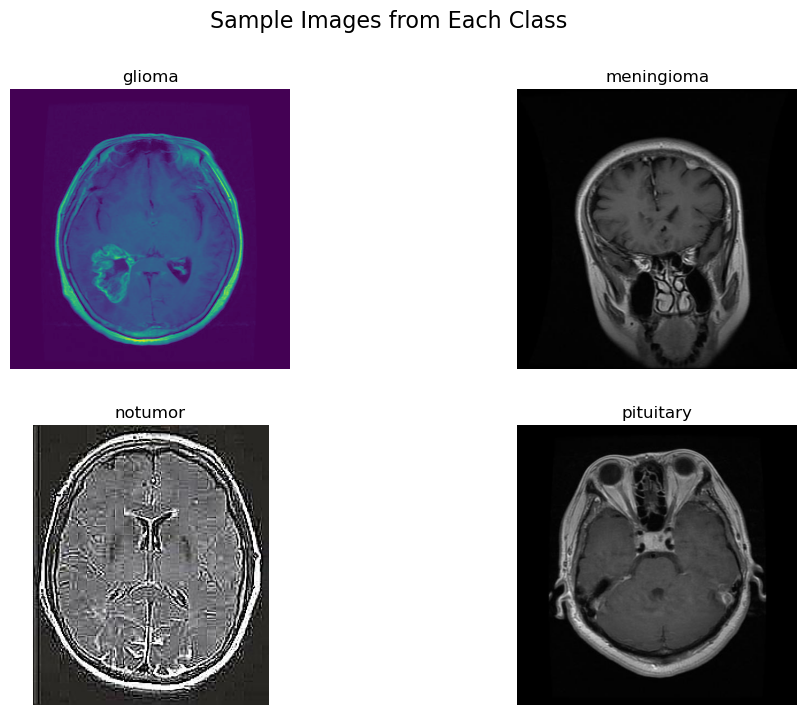

In [11]:
plot.figure(figsize=(12, 8))
for class_index, class_name in enumerate(label_names):
    class_folder = os.path.join(train_path, class_name)
    image_files = [
        file_item for file_item in os.listdir(class_folder)
        if file_item.lower().endswith(('.png', '.jpg', '.jpeg'))]

    sample_image_path = os.path.join(class_folder, image_files[0])
    sample_image = plot.imread(sample_image_path)

    plot.subplot(2, 2, class_index + 1)
    plot.imshow(sample_image)
    plot.title(class_name)
    plot.axis('off')

plot.suptitle("Sample Images from Each Class", fontsize=16)
plot.show()